## Laboratorio 4

1. Construya un `DataFrame` de pandas con un conjunto de datos lineales simples.

In [12]:
# Importar las librerías necesarias
import numpy as np
import pandas as pd

# Crear datos lineales simples pero con más ruido
X = np.linspace(0, 10, 20)
np.random.seed(42)  # Para reproducibilidad
y = 2.5 * X + 1.0 + np.random.normal(0, 0, size=X.shape)  # Añadir ruido gaussiano (desviación 5)

# Construir el DataFrame
df = pd.DataFrame({'X': X, 'Y': y})

# Mostrar el DataFrame
print("Conjunto de datos lineales simples con ruido:")
print(df)

Conjunto de datos lineales simples con ruido:
            X          Y
0    0.000000   1.000000
1    0.526316   2.315789
2    1.052632   3.631579
3    1.578947   4.947368
4    2.105263   6.263158
5    2.631579   7.578947
6    3.157895   8.894737
7    3.684211  10.210526
8    4.210526  11.526316
9    4.736842  12.842105
10   5.263158  14.157895
11   5.789474  15.473684
12   6.315789  16.789474
13   6.842105  18.105263
14   7.368421  19.421053
15   7.894737  20.736842
16   8.421053  22.052632
17   8.947368  23.368421
18   9.473684  24.684211
19  10.000000  26.000000


2. Defina una función que calcule la función de coste cuadrática para un modelo de regresión lineal.

\begin{equation}
J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}\left((\theta_0+\theta_1x^{(i)})-y^{(i)}\right)^2
\end{equation}

In [13]:
# Definir la función de coste cuadrática para regresión lineal
def funcion_coste_cuadratica(X, y, theta_0, theta_1):
    """
    Calcula la función de coste cuadrática J para regresión lineal.
    Parámetros:
        X: array-like, variable independiente
        y: array-like, variable dependiente
        theta_0: float, parámetro de sesgo
        theta_1: float, parámetro de pendiente
    Retorna:
        J: float, valor de la función de coste
    """
    m = len(y)
    predicciones = theta_0 + theta_1 * X
    error = predicciones - y
    J = (1/(2*m)) * np.sum(error**2)
    return J

# Ejemplo de uso
J_ejemplo = funcion_coste_cuadratica(df['X'], df['Y'], theta_0=0, theta_1=1)
print(f"Ejemplo de función de coste cuadrática (theta_0=0, theta_1=1): {J_ejemplo:.4f}")

Ejemplo de función de coste cuadrática (theta_0=0, theta_1=1): 46.4868


3. Fijando inicialmente $\theta_0=0$, evalúe y grafique la función de coste para diferentes valores de $\theta_1$. Determine el valor que minimiza la función de coste y grafique la recta obtenida sobre los datos.

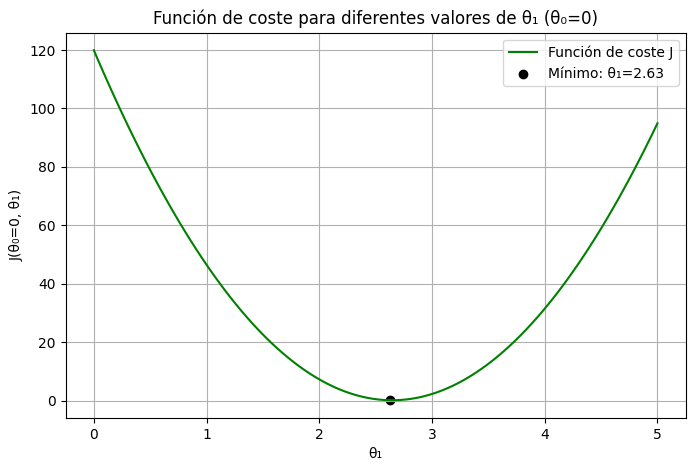

El valor de θ₁ que minimiza la función de coste es: 2.6263


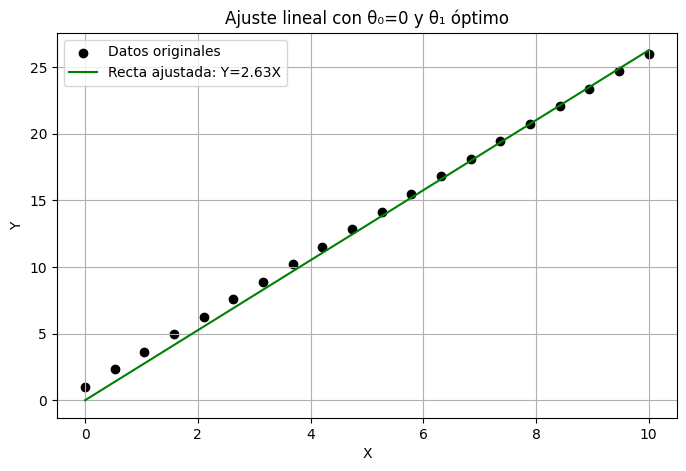

In [14]:
# Evaluar y graficar la función de coste para diferentes valores de theta_1 con theta_0=0
import matplotlib.pyplot as plt

# Rango de valores para theta_1
theta_1_vals = np.linspace(0, 5, 100)
costes = []

# Calcular la función de coste para cada valor de theta_1
for t1 in theta_1_vals:
    J = funcion_coste_cuadratica(df['X'], df['Y'], theta_0=0, theta_1=t1)
    costes.append(J)

# Encontrar el valor de theta_1 que minimiza la función de coste
indice_min = np.argmin(costes)
theta_1_min = theta_1_vals[indice_min]
J_min = costes[indice_min]

# Graficamos la función de coste
plt.figure(figsize=(8,5))
plt.plot(theta_1_vals, costes, label='Función de coste J', color = 'green')
plt.scatter(theta_1_min, J_min, color='black', label=f'Mínimo: θ₁={theta_1_min:.2f}')
plt.xlabel('θ₁')
plt.ylabel('J(θ₀=0, θ₁)')
plt.title('Función de coste para diferentes valores de θ₁ (θ₀=0)')
plt.legend()
plt.grid()
plt.show()

print(f"El valor de θ₁ que minimiza la función de coste es: {theta_1_min:.4f}")

# Graficamo ahora la recta obtenida sobre los datos
plt.figure(figsize=(8,5))
plt.scatter(df['X'], df['Y'], label='Datos originales', color  = 'black')
plt.plot(df['X'], theta_1_min * df['X'], color='green', label=f'Recta ajustada: Y={theta_1_min:.2f}X')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Ajuste lineal con θ₀=0 y θ₁ óptimo')
plt.legend()
plt.grid()
plt.show()

4. Permita ahora que tanto $\theta_0$ como $\theta_1$ varíen. Construya una malla con `np.meshgrid`, evalúe la función de coste en cada punto y represente su superficie y curvas de nivel.

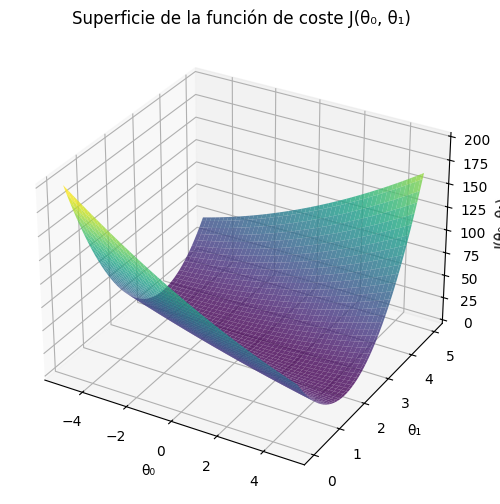

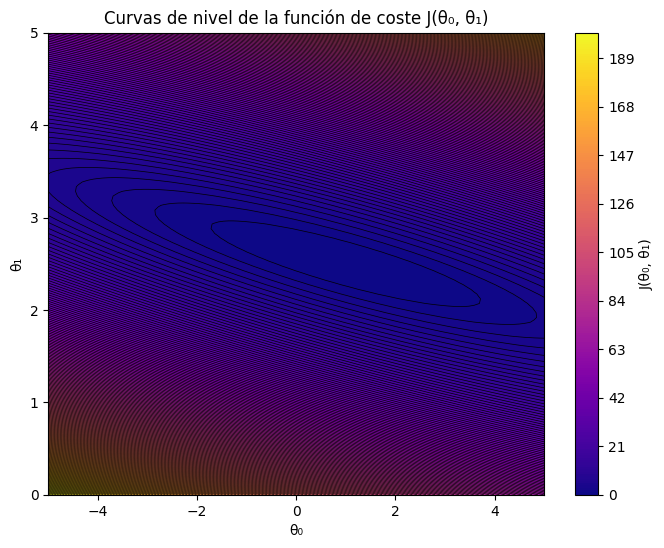

In [15]:
# Permitir que tanto theta_0 como theta_1 varíen y graficar la superficie y curvas de nivel de la función de coste

# Definir rangos para theta_0 y theta_1
theta_0_vals = np.linspace(-5, 5, 100)
theta_1_vals = np.linspace(0, 5, 100)

# Crear la malla de valores
T0, T1 = np.meshgrid(theta_0_vals, theta_1_vals)
J_vals = np.zeros_like(T0)

# Evaluar la función de coste en cada punto de la malla
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        J_vals[i, j] = funcion_coste_cuadratica(df['X'], df['Y'], T0[i, j], T1[i, j])

# Graficar la superficie 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T0, T1, J_vals, cmap='viridis', alpha=0.8)
ax.set_xlabel('θ₀')
ax.set_ylabel('θ₁')
ax.set_zlabel('J(θ₀, θ₁)')
ax.set_title('Superficie de la función de coste J(θ₀, θ₁)')
plt.show()

# Graficar las curvas de nivel (contour)
plt.figure(figsize=(8,6))
contour = plt.contourf(T0, T1, J_vals, levels=200, cmap='plasma')
contour_2 = plt.contour(T0, T1, J_vals, levels=200, colors='black', linewidths=0.5)
plt.xlabel('θ₀')
plt.ylabel('θ₁')
plt.title('Curvas de nivel de la función de coste J(θ₀, θ₁)')
plt.colorbar(contour, label='J(θ₀, θ₁)')
#plt.colorbar(contour_2)
plt.show()

5. Interprete geométricamente la forma de la función de coste e identifique el mínimo global.

Geométricamente, la función de coste cuadrática $( J(\theta_0, \theta_1) )$ tiene forma de un "valle" o parábola en dos dimensiones, conocido como superficie parabólica.
Las curvas de nivel que se graficaron en el plano $((\theta_0, \theta_1))$ son elipses concéntricas: cada curva representa los valores de $((\theta_0, \theta_1))$ que producen el mismo coste.

El mínimo global de la función de coste es el punto más bajo de este valle, es decir, el centro de las elipses. Ese punto corresponde a los valores óptimos de $(\theta_0)$ y $(\theta_1)$ que mejor ajustan la recta a los datos, minimizando el error cuadrático medio entre las predicciones y los valores reales.

6. Repita el procedimiento para un conjunto de datos con ruido y compare los resultados con el caso ideal.

In [16]:
# Importar las librerías necesarias
import numpy as np
import pandas as pd

# Crear datos lineales simples pero con más ruido
X1 = np.linspace(0, 10, 20)
np.random.seed(42)  # Para reproducibilidad
y1 = 2.5 * X1 + 1.0 + np.random.normal(0, 5, size=X1.shape)  # Añadir ruido gaussiano (desviación 5)

# Construir el DataFrame
df1 = pd.DataFrame({'X': X1, 'Y': y1})

# Mostrar el DataFrame
print("Conjunto de datos lineales simples con ruido:")
print(df1)

Conjunto de datos lineales simples con ruido:
            X          Y
0    0.000000   3.483571
1    0.526316   1.624468
2    1.052632   6.870022
3    1.578947  12.562518
4    2.105263   5.092391
5    2.631579   6.408263
6    3.157895  16.790801
7    3.684211  14.047700
8    4.210526   9.178944
9    4.736842  15.554905
10   5.263158  11.840806
11   5.789474  13.145035
12   6.315789  17.999285
13   6.842105   8.538862
14   7.368421  10.796463
15   7.894737  17.925404
16   8.421053  16.988476
17   8.947368  24.939658
18   9.473684  20.144090
19  10.000000  18.938481


In [17]:
# Definir la función de coste cuadrática para regresión lineal
def funcion_coste_cuadratica(X1, y1, theta_01, theta_11):
    """
    Calcula la función de coste cuadrática J para regresión lineal.
    Parámetros:
        X: array-like, variable independiente
        y: array-like, variable dependiente
        theta_0: float, parámetro de sesgo
        theta_1: float, parámetro de pendiente
    Retorna:
        J: float, valor de la función de coste
    """
    m1 = len(y1)
    predicciones1 = theta_01 + theta_11 * X1
    error1 = predicciones1 - y1
    J1 = (1/(2*m1)) * np.sum(error1**2)
    return J1

# Ejemplo de uso
J1_ejemplo = funcion_coste_cuadratica(df1['X'], df1['Y'], theta_01=0, theta_11=1)
print(f"Ejemplo de función de coste cuadrática (theta_0=0, theta_1=1): {J1_ejemplo:.4f}")

Ejemplo de función de coste cuadrática (theta_0=0, theta_1=1): 37.4502


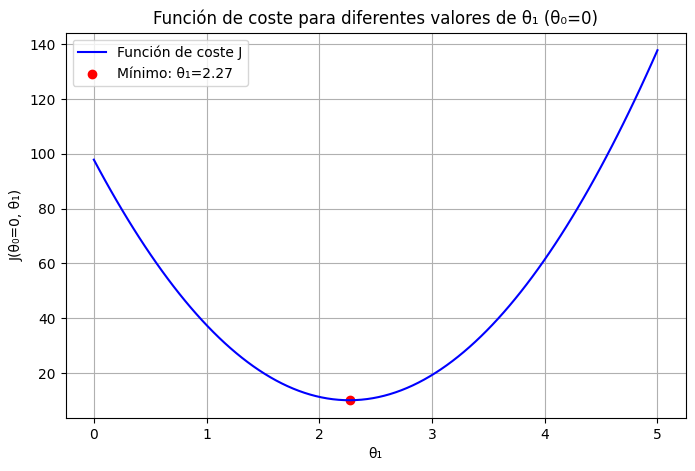

El valor de θ₁ que minimiza la función de coste es: 2.2727


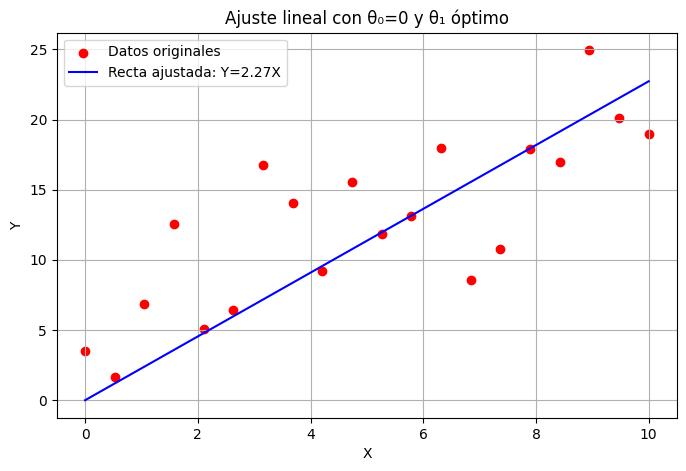

In [18]:
# Evaluar y graficar la función de coste para diferentes valores de theta_1 con theta_0=0
import matplotlib.pyplot as plt

# Rango de valores para theta_1
theta_1_vals1 = np.linspace(0, 5, 100)
costes1 = []

# Calcular la función de coste para cada valor de theta_1
for t11 in theta_1_vals1:
    J1 = funcion_coste_cuadratica(df1['X'], df1['Y'], theta_01=0, theta_11=t11)
    costes1.append(J1)

# Encontrar el valor de theta_1 que minimiza la función de coste
indice_min1 = np.argmin(costes1)
theta_1_min1 = theta_1_vals1[indice_min1]
J_min1 = costes1[indice_min1]

# Graficamos la función de coste
plt.figure(figsize=(8,5))
plt.plot(theta_1_vals1, costes1, label='Función de coste J', color = 'blue')
plt.scatter(theta_1_min1, J_min1, color='red', label=f'Mínimo: θ₁={theta_1_min1:.2f}')
plt.xlabel('θ₁')
plt.ylabel('J(θ₀=0, θ₁)')
plt.title('Función de coste para diferentes valores de θ₁ (θ₀=0)')
plt.legend()
plt.grid()
plt.show()

print(f"El valor de θ₁ que minimiza la función de coste es: {theta_1_min1:.4f}")

# Graficamo ahora la recta obtenida sobre los datos
plt.figure(figsize=(8,5))
plt.scatter(df1['X'], df1['Y'], label='Datos originales', color  = 'red')
plt.plot(df1['X'], theta_1_min1 * df1['X'], color='blue', label=f'Recta ajustada: Y={theta_1_min1:.2f}X')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Ajuste lineal con θ₀=0 y θ₁ óptimo')
plt.legend()
plt.grid()
plt.show()

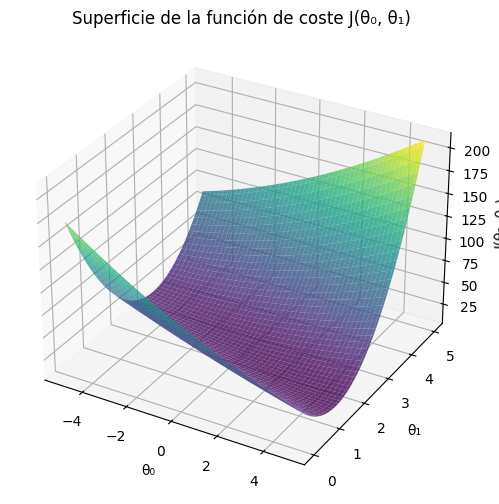

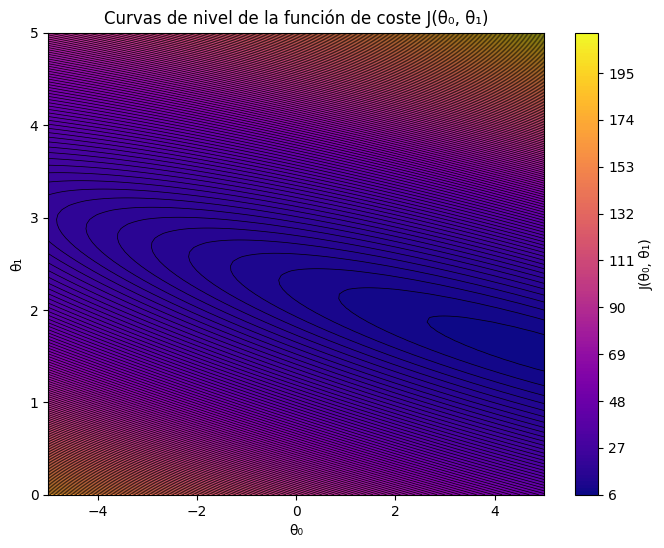

In [19]:
# Permitir que tanto theta_0 como theta_1 varíen y graficar la superficie y curvas de nivel de la función de coste

# Definir rangos para theta_0 y theta_1
theta_0_vals1 = np.linspace(-5, 5, 100)
theta_1_vals1 = np.linspace(0, 5, 100)

# Crear la malla de valores
T01, T11 = np.meshgrid(theta_0_vals1, theta_1_vals1)
J_vals1 = np.zeros_like(T01)

# Evaluar la función de coste en cada punto de la malla
for i in range(T01.shape[0]):
    for j in range(T01.shape[1]):
        J_vals1[i, j] = funcion_coste_cuadratica(df1['X'], df1['Y'], T01[i, j], T11[i, j])

# Graficar la superficie 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T01, T11, J_vals1, cmap='viridis', alpha=0.8)
ax.set_xlabel('θ₀')
ax.set_ylabel('θ₁')
ax.set_zlabel('J(θ₀, θ₁)')
ax.set_title('Superficie de la función de coste J(θ₀, θ₁)')
plt.show()

# Graficar las curvas de nivel (contour)
plt.figure(figsize=(8,6))
contour1 = plt.contourf(T01, T11, J_vals1, levels=200, cmap='plasma')
contour_21 = plt.contour(T01, T11, J_vals1, levels=200, colors='black', linewidths=0.5)
plt.xlabel('θ₀')
plt.ylabel('θ₁')
plt.title('Curvas de nivel de la función de coste J(θ₀, θ₁)')
plt.colorbar(contour1, label='J(θ₀, θ₁)')
#plt.colorbar(contour_2)
plt.show()

## Comparativa datos lineales vs datos con ruido

## Función de coste

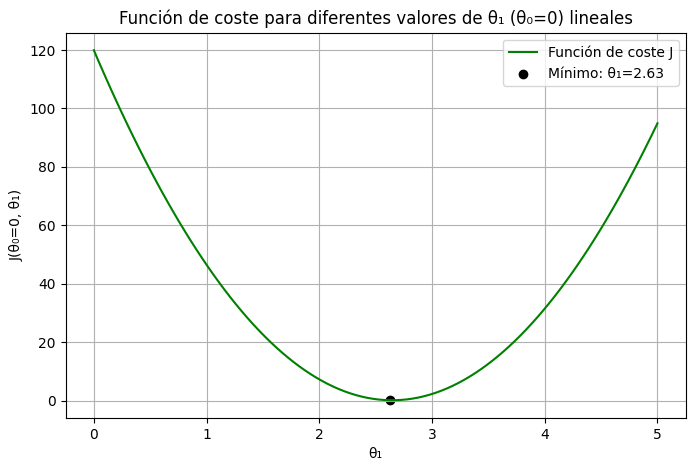

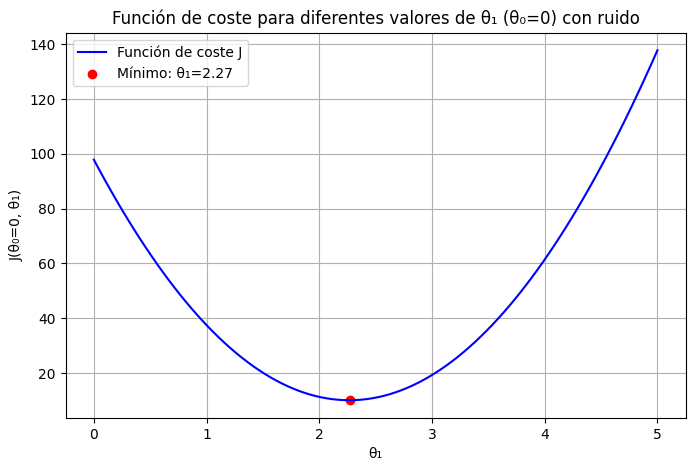

In [20]:
# Graficamos la función de coste lineal
plt.figure(figsize=(8,5))
plt.plot(theta_1_vals, costes, label='Función de coste J', color = 'green')
plt.scatter(theta_1_min, J_min, color='black', label=f'Mínimo: θ₁={theta_1_min:.2f}')
plt.xlabel('θ₁')
plt.ylabel('J(θ₀=0, θ₁)')
plt.title('Función de coste para diferentes valores de θ₁ (θ₀=0) lineales')
plt.legend()
plt.grid()
plt.show()

# Graficamos la función de coste con ruido
plt.figure(figsize=(8,5))
plt.plot(theta_1_vals1, costes1, label='Función de coste J', color = 'blue')
plt.scatter(theta_1_min1, J_min1, color='red', label=f'Mínimo: θ₁={theta_1_min1:.2f}')
plt.xlabel('θ₁')
plt.ylabel('J(θ₀=0, θ₁)')
plt.title('Función de coste para diferentes valores de θ₁ (θ₀=0) con ruido')
plt.legend()
plt.grid()
plt.show()

En este caso de la función de coste podemos observar que:

Cuando los datos son lineales (sin ruido), el valor óptimo de $(\theta_1)$ (pendiente) se ajusta exactamente a la relación real entre $(X)$ y $(Y)$, en este caso cercano a $2.63$, que es el valor teórico esperado (por la ecuación $(y = 2.5x + 1)$, aunque existe una variación ligera por el muestreo).

Cuando introducimos ruido en los datos, la relación entre $(X)$ y $(Y)$ se vuelve menos exacta. El modelo de regresión lineal busca el mejor ajuste promedio, pero el ruido hace que algunos puntos estén alejados de la recta ideal. Por eso, el valor óptimo de ($\theta_1$) baja a $2.32$ : implicando que el modelo intenta minimizar el error cuadrático medio, pero no puede ajustarse perfectamente a todos los puntos debido al ruido.


## Ajuste Lineal

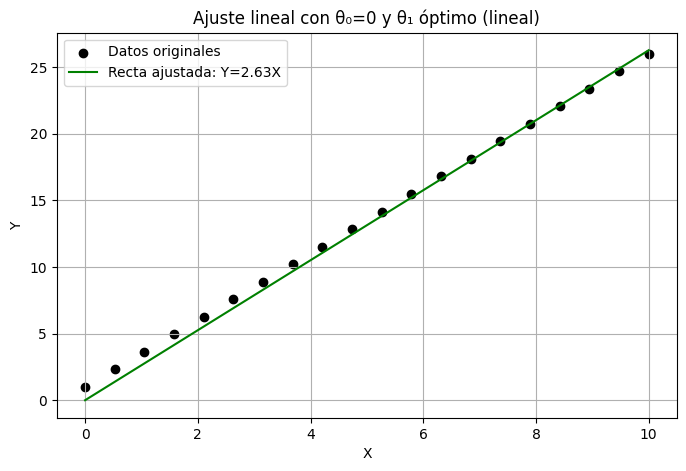

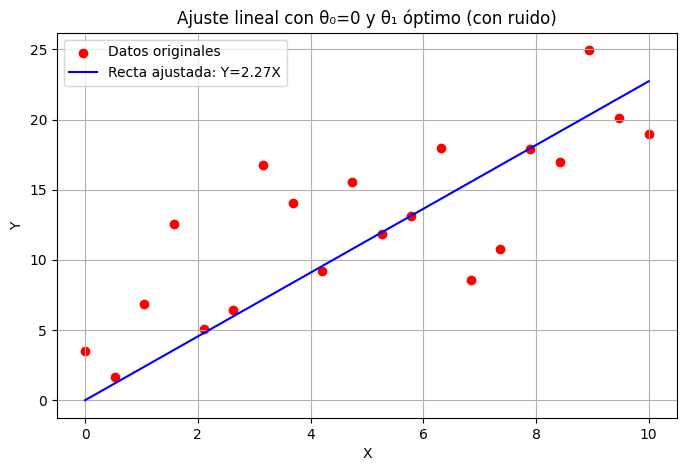

In [ ]:
# Graficamo ahora la recta obtenida sobre los datos
plt.figure(figsize=(8,5))
plt.scatter(df['X'], df['Y'], label='Datos originales', color  = 'black')
plt.plot(df['X'], theta_1_min * df['X'], color='green', label=f'Recta ajustada: Y={theta_1_min:.2f}X')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Ajuste lineal con θ₀=0 y θ₁ óptimo (linead)')
plt.legend()
plt.grid()
plt.show()

# Graficamo ahora la recta obtenida sobre los datos
plt.figure(figsize=(8,5))
plt.scatter(df1['X'], df1['Y'], label='Datos originales', color  = 'red')
plt.plot(df1['X'], theta_1_min1 * df1['X'], color='blue', label=f'Recta ajustada: Y={theta_1_min1:.2f}X')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Ajuste lineal con θ₀=0 y θ₁ óptimo (con ruido)')
plt.legend()
plt.grid()
plt.show()



La comparación entre los ajustes lineales sin ruido y con ruido muestra claramente el impacto de la función de coste en la calidad del ajuste:

**Sin ruido:**

Como esperabamos, la función de coste alcanza su mínimo global cuando la recta ajustada coincide casi perfectamente con los datos, ya que todos los puntos siguen exactamente la relación lineal. El valor óptimo de la pendiente ($(\theta_1)$) es muy cercano al valor teórico, y el error cuadrático medio es mínimo.

**Con ruido:**

Así mismo, la función de coste es mayor, ya que el modelo no puede ajustarse perfectamente a todos los puntos debido a la dispersión introducida por el ruido. El valor óptimo de ($\theta_1$) se aleja del valor teórico, reflejando que el modelo busca el mejor ajuste promedio, pero algunos puntos estarán lejos de la recta. El error cuadrático medio aumenta.

